In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

In [2]:
train = pd.read_csv("DailyDelhiClimateTrain.csv")
test = pd.read_csv("DailyDelhiClimateTest.csv")

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

columns = [
    "meantemp",
    "humidity",
    "wind_speed",
    "meanpressure"
]

print(train.head())
print(train.shape)
print(test.shape)

        date   meantemp   humidity  wind_speed  meanpressure
0 2013-01-01  10.000000  84.500000    0.000000   1015.666667
1 2013-01-02   7.400000  92.000000    2.980000   1017.800000
2 2013-01-03   7.166667  87.000000    4.633333   1018.666667
3 2013-01-04   8.666667  71.333333    1.233333   1017.166667
4 2013-01-05   6.000000  86.833333    3.700000   1016.500000
(1462, 5)
(114, 5)


In [3]:
# Исправляем явно ошибочные значения давления.
# Значения, сильно выходящие за нормальный диапазон,
# заменяем пропусками, а потом интерполируем.

for df in [train, test]:
    mask = (df["meanpressure"] < 900) | (df["meanpressure"] > 1100)
    df.loc[mask, "meanpressure"] = np.nan

    df["meanpressure"] = (
        df["meanpressure"]
        .interpolate()
        .bfill()
        .ffill()
    )

In [4]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0

    mape = np.mean(
        np.abs(
            (y_true[mask] - y_pred[mask]) /
            y_true[mask]
        )
    ) * 100

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

SARIMA

In [5]:
def run_sarima(
    train,
    test,
    column,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 7)
):

    train_values = train[column].values
    test_values = test[column].values

    model = SARIMAX(
        train_values,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    predictions = model_fit.forecast(
        steps=len(test_values)
    )

    metrics = calculate_metrics(
        test_values,
        predictions
    )

    return predictions, metrics

In [6]:
sarima_results = {}

for column in columns:

    print("\nSARIMA:", column)

    predictions, metrics = run_sarima(
        train,
        test,
        column,
        order=(2, 1, 2),
        seasonal_order=(1, 1, 1, 7)
    )

    sarima_results[column] = {
        "predictions": predictions,
        "metrics": metrics
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")


SARIMA: meantemp
MAE: 8.5873
MSE: 111.2140
RMSE: 10.5458
R2: -1.7737
MAPE: 34.7599

SARIMA: humidity
MAE: 29.1098
MSE: 1195.9795
RMSE: 34.5829
R2: -2.3185
MAPE: 75.7429

SARIMA: wind_speed


/home/mlguest/miniforge3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


MAE: 3.1270
MSE: 16.1930
RMSE: 4.0241
R2: -0.2689
MAPE: 44.6184

SARIMA: meanpressure
MAE: 5.2749
MSE: 46.2031
RMSE: 6.7973
R2: -0.4290
MAPE: 0.5231


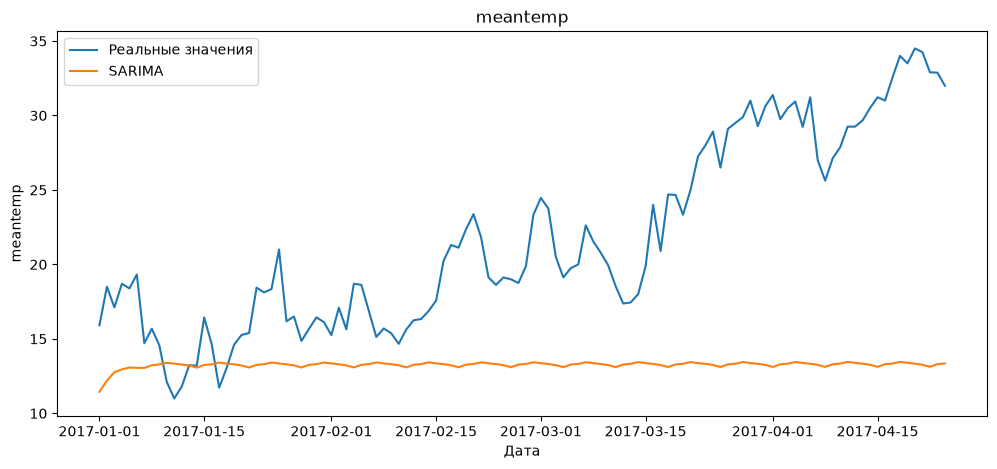

In [7]:
column = "meantemp"

plt.figure(figsize=(12, 5))

plt.plot(
    test["date"],
    test[column],
    label="Реальные значения"
)

plt.plot(
    test["date"],
    sarima_results[column]["predictions"],
    label="SARIMA"
)

plt.title(column)
plt.xlabel("Дата")
plt.ylabel(column)
plt.legend()

plt.show()

GRU

In [8]:
def create_sequences(data, window=30):

    X = []
    y = []

    for i in range(window, len(data)):

        X.append(
            data[i-window:i]
        )

        y.append(
            data[i]
        )

    return np.array(X), np.array(y)

In [9]:
def run_gru_walk_forward(
    train,
    test,
    column,
    window=60,
    epochs=100,
    batch_size=32
):

    train_values = train[[column]].values.astype("float32")
    test_values = test[[column]].values.astype("float32")

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train_values)

    X_train, y_train = create_sequences(
        train_scaled,
        window
    )

    X_train = X_train.reshape(
        X_train.shape[0],
        X_train.shape[1],
        1
    )

    model = Sequential([
        Input(shape=(window, 1)),
        GRU(64, use_cudnn=False),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop],
        verbose=1
    )

    history = list(train_values.flatten())

    predictions = []

    for actual in test_values.flatten():

        window_values = np.array(
            history[-window:]
        ).reshape(-1, 1)

        window_scaled = scaler.transform(
            window_values
        )

        x = window_scaled.reshape(
            1,
            window,
            1
        )

        pred_scaled = model.predict(
            x,
            verbose=0
        )[0, 0]

        pred = scaler.inverse_transform(
            [[pred_scaled]]
        )[0, 0]

        predictions.append(pred)

        history.append(actual)

    predictions = np.array(predictions)

    metrics = calculate_metrics(
        test_values.flatten(),
        predictions
    )

    return predictions, metrics, model

In [10]:
gru_results = {}

for column in columns:

    print("\nGRU:", column)

    predictions, metrics, model = run_gru_walk_forward(
        train,
        test,
        column,
        window=60,
        epochs=100
    )

    gru_results[column] = {
        "predictions": predictions,
        "metrics": metrics
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")


GRU: meantemp


W0000 00:00:1791374128.278068  812398 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1791374128.347951  812398 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.


Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1052
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0097
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030
Epoch 13/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029
Epoch 14/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029
Epoch 15/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029
Epo

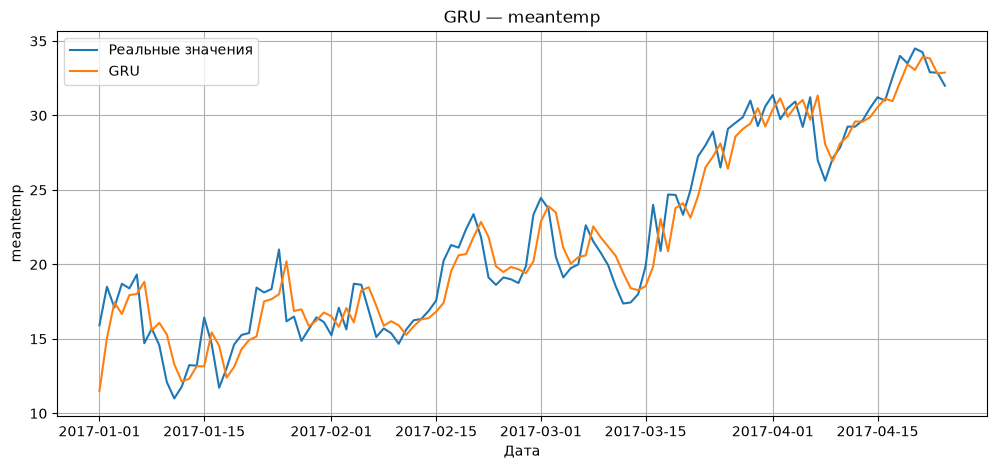

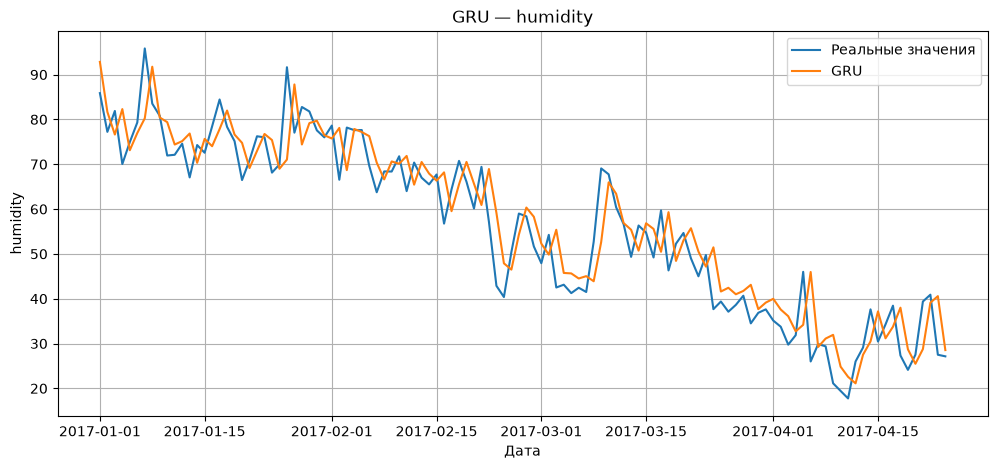

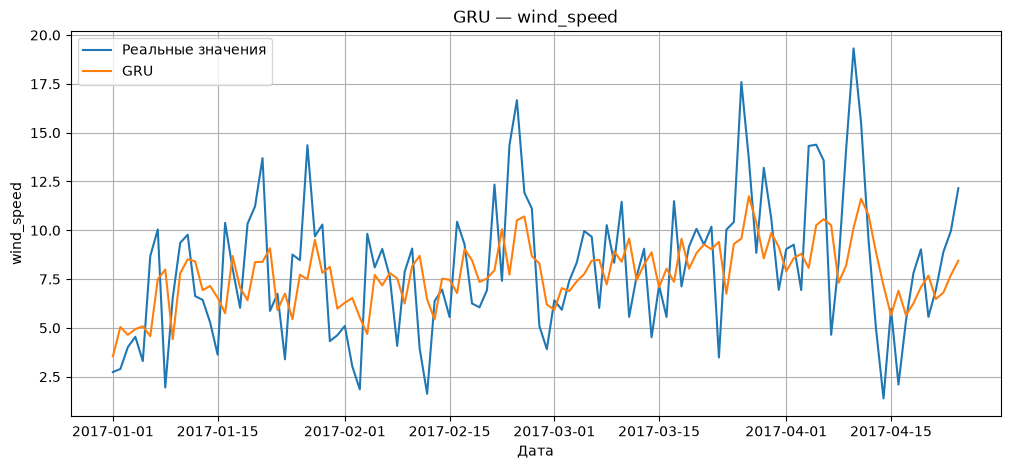

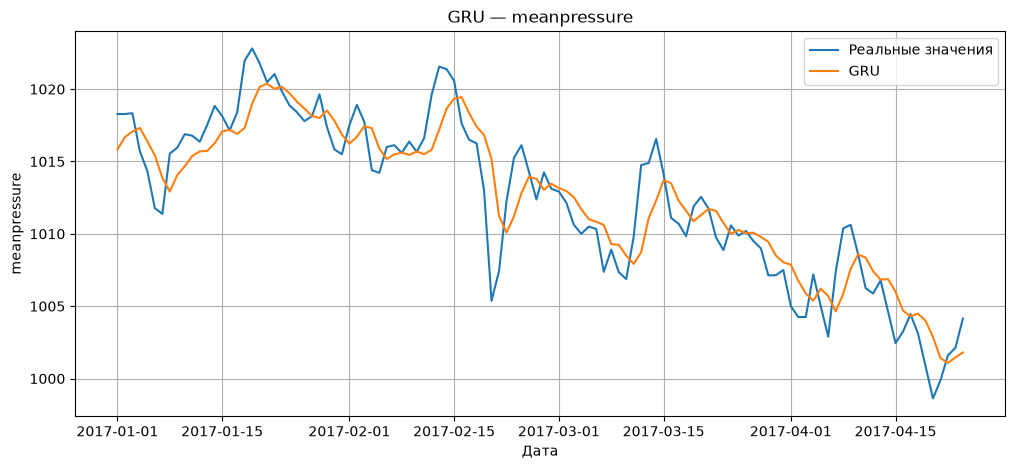

In [11]:
for column in columns:

    plt.figure(figsize=(12, 5))

    plt.plot(
        test["date"],
        test[column],
        label="Реальные значения"
    )

    plt.plot(
        test["date"],
        gru_results[column]["predictions"],
        label="GRU"
    )

    plt.title(f"GRU — {column}")
    plt.xlabel("Дата")
    plt.ylabel(column)

    plt.legend()
    plt.grid(True)

    plt.show()

LSTM

In [12]:
def run_lstm_walk_forward(
    train,
    test,
    column,
    window=60,
    epochs=100,
    batch_size=32
):

    train_values = train[[column]].values.astype("float32")
    test_values = test[[column]].values.astype("float32")

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train_values)

    X_train, y_train = create_sequences(
        train_scaled,
        window
    )

    X_train = X_train.reshape(
        X_train.shape[0],
        X_train.shape[1],
        1
    )

    model = Sequential([
        Input(shape=(window, 1)),
        LSTM(64, use_cudnn=False),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop],
        verbose=1
    )

    history = list(train_values.flatten())

    predictions = []

    for actual in test_values.flatten():

        # Берём последние реальные значения
        window_values = np.array(
            history[-window:]
        ).reshape(-1, 1)

        # Нормализуем
        window_scaled = scaler.transform(
            window_values
        )

        x = window_scaled.reshape(
            1,
            window,
            1
        )

        # Прогноз
        pred_scaled = model.predict(
            x,
            verbose=0
        )[0, 0]

        pred = scaler.inverse_transform(
            [[pred_scaled]]
        )[0, 0]

        predictions.append(pred)

        # Добавляем реальное значение test
        history.append(actual)

    predictions = np.array(predictions)

    metrics = calculate_metrics(
        test_values.flatten(),
        predictions
    )

    return predictions, metrics, model

In [13]:
lstm_results = {}

for column in columns:

    print("\nLSTM:", column)

    predictions, metrics, model = run_lstm_walk_forward(
        train,
        test,
        column,
        window=60,
        epochs=100
    )

    lstm_results[column] = {
        "predictions": predictions,
        "metrics": metrics
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")


LSTM: meantemp
Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0692
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0049
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0047
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0045
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0044
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041
Epoch 13/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041
Epoch 14/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0040
Epoch 15/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - 

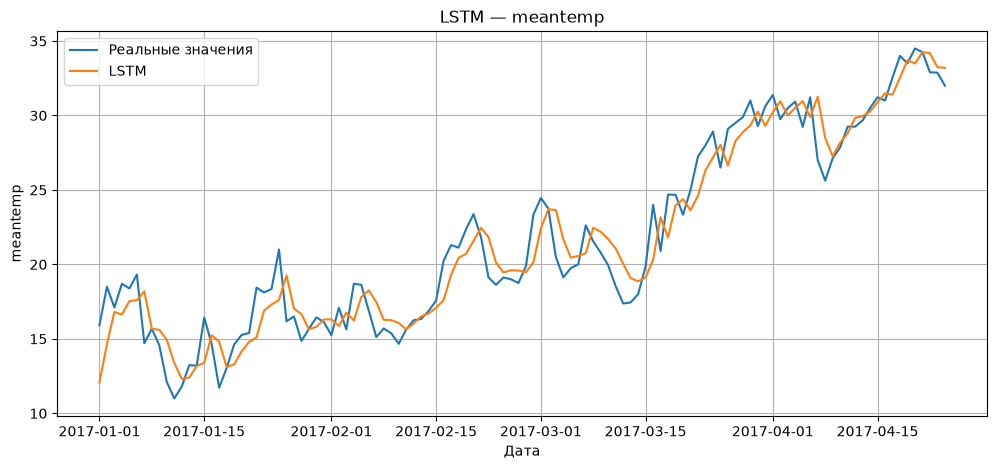

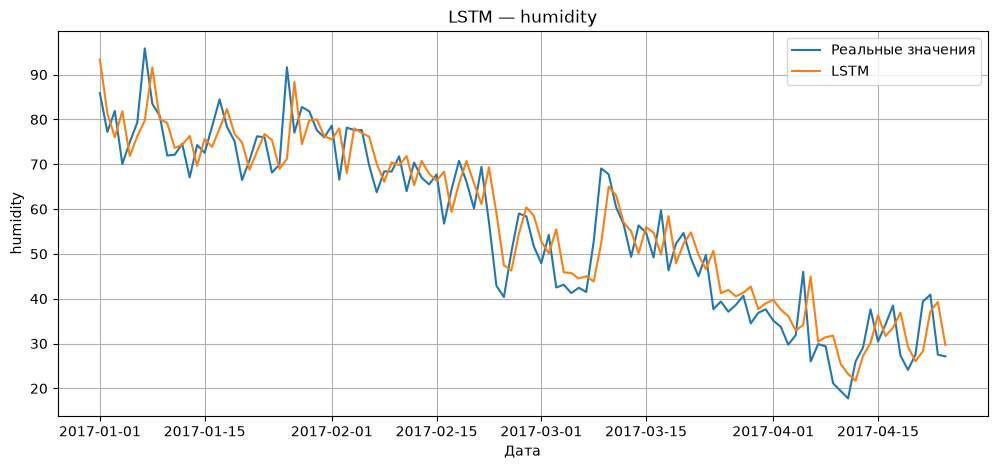

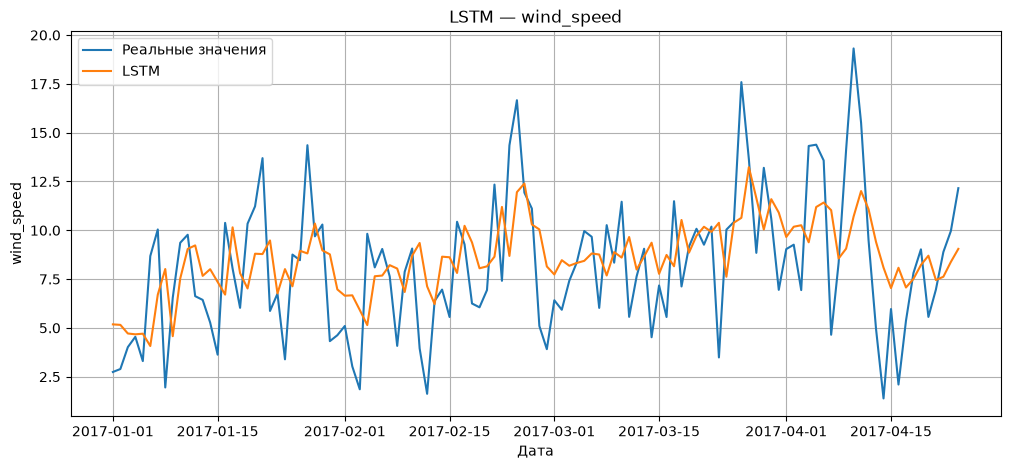

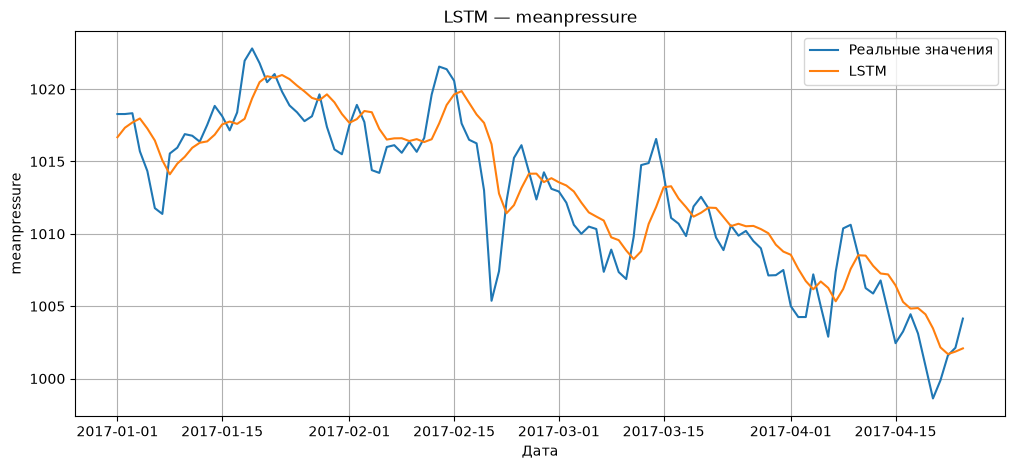

In [14]:
for column in columns:

    plt.figure(figsize=(12, 5))

    plt.plot(
        test["date"],
        test[column],
        label="Реальные значения"
    )

    plt.plot(
        test["date"],
        lstm_results[column]["predictions"],
        label="LSTM"
    )

    plt.title(f"LSTM — {column}")
    plt.xlabel("Дата")
    plt.ylabel(column)

    plt.legend()
    plt.grid(True)

    plt.show()

In [15]:
results_table = []

for column in columns:

    # GRU
    gru_metrics = gru_results[column]["metrics"]

    results_table.append({
        "Показатель": column,
        "Модель": "GRU",
        "MAE": gru_metrics["MAE"],
        "MSE": gru_metrics["MSE"],
        "RMSE": gru_metrics["RMSE"],
        "R²": gru_metrics["R2"],
        "MAPE, %": gru_metrics["MAPE"]
    })

    # LSTM
    lstm_metrics = lstm_results[column]["metrics"]

    results_table.append({
        "Показатель": column,
        "Модель": "LSTM",
        "MAE": lstm_metrics["MAE"],
        "MSE": lstm_metrics["MSE"],
        "RMSE": lstm_metrics["RMSE"],
        "R²": lstm_metrics["R2"],
        "MAPE, %": lstm_metrics["MAPE"]
    })


results_df = pd.DataFrame(results_table)

# Округляем
results_df = results_df.round(4)

results_df

,Показатель,Модель,MAE,MSE,RMSE,R²,"MAPE, %"
0,meantemp,GRU,1.3728,3.0583,1.7488,0.9237,6.9918
1,meantemp,LSTM,1.3762,2.9720,1.7239,0.9259,6.9891
2,humidity,GRU,5.5324,49.3576,7.0255,0.8630,11.6441
3,humidity,LSTM,5.5542,48.7892,6.9849,0.8646,11.6282
4,wind_speed,GRU,2.5197,9.9874,3.1603,0.2174,43.4411
5,wind_speed,LSTM,2.5520,10.1128,3.1801,0.2075,48.2869
6,meanpressure,GRU,1.8056,5.3538,2.3138,0.8344,0.1784
7,meanpressure,LSTM,1.9564,6.2978,2.5095,0.8052,0.1934


Прогноз на 7/14 дней сразу

In [16]:
def create_sequences_multistep(data, window=60, horizon=7):

    X = []
    y = []

    for i in range(window, len(data) - horizon + 1):

        # предыдущие window значений
        X.append(data[i-window:i])

        # сразу следующие horizon значений
        y.append(data[i:i+horizon].flatten())

    return np.array(X), np.array(y)

In [17]:
def run_gru_multistep(
    train,
    test,
    column,
    window=60,
    horizon=7,
    epochs=100,
    batch_size=32
):

    train_values = train[[column]].values.astype("float32")
    test_values = test[[column]].values.astype("float32")

    scaler = MinMaxScaler()

    # scaler обучаем только на train
    train_scaled = scaler.fit_transform(train_values)

    X_train, y_train = create_sequences_multistep(
        train_scaled,
        window,
        horizon
    )

    X_train = X_train.reshape(
        X_train.shape[0],
        window,
        1
    )

    # Последние 20% train для validation
    split = int(len(X_train) * 0.8)

    X_tr = X_train[:split]
    y_tr = y_train[:split]

    X_val = X_train[split:]
    y_val = y_train[split:]

    model = Sequential([
        Input(shape=(window, 1)),

        GRU(
            64,
            use_cudnn=False
        ),

        # ВАЖНО:
        # сразу horizon выходов
        Dense(horizon)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop],
        verbose=1
    )

    # Берём последние window значений train
    last_window = train_scaled[-window:]

    x = last_window.reshape(
        1,
        window,
        1
    )

    # СРАЗУ прогнозируем horizon дней
    pred_scaled = model.predict(
        x,
        verbose=0
    )[0]

    # inverse_transform требует форму (n, 1)
    predictions = scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).flatten()

    # Первые horizon реальных значений test
    actual = test_values[:horizon].flatten()

    metrics = calculate_metrics(
        actual,
        predictions
    )

    return predictions, actual, metrics, model

In [18]:
gru_7_results = {}

for column in columns:

    print("\nGRU 7 дней:", column)

    predictions, actual, metrics, model = run_gru_multistep(
        train,
        test,
        column,
        window=60,
        horizon=7,
        epochs=100
    )

    gru_7_results[column] = {
        "predictions": predictions,
        "actual": actual,
        "metrics": metrics
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")


GRU 7 дней: meantemp
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.1982 - val_loss: 0.0150
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0141 - val_loss: 0.0089
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0105 - val_loss: 0.0074
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0085 - val_loss: 0.0061
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074 - val_loss: 0.0057
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0070 - val_loss: 0.0055
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0069 - val_loss: 0.0055
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0068 - val_loss: 0.0054
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 - val_loss: 0.0054
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 - val_loss: 0.0053
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_loss: 0.0053
Epoch 12/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 

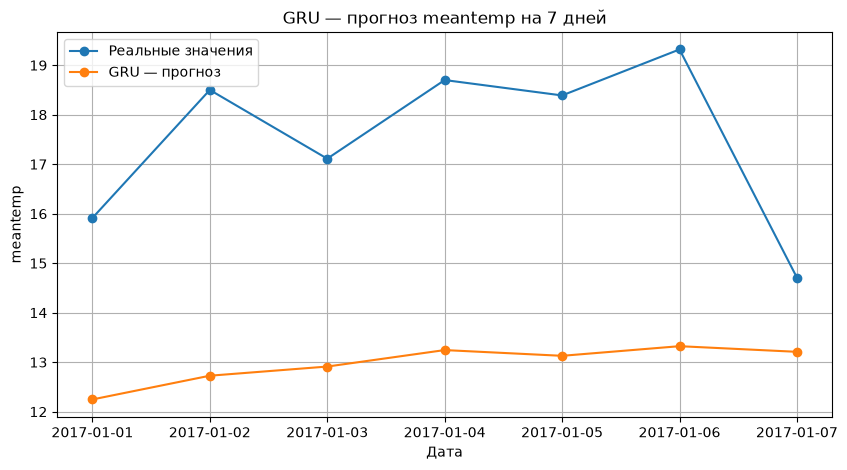

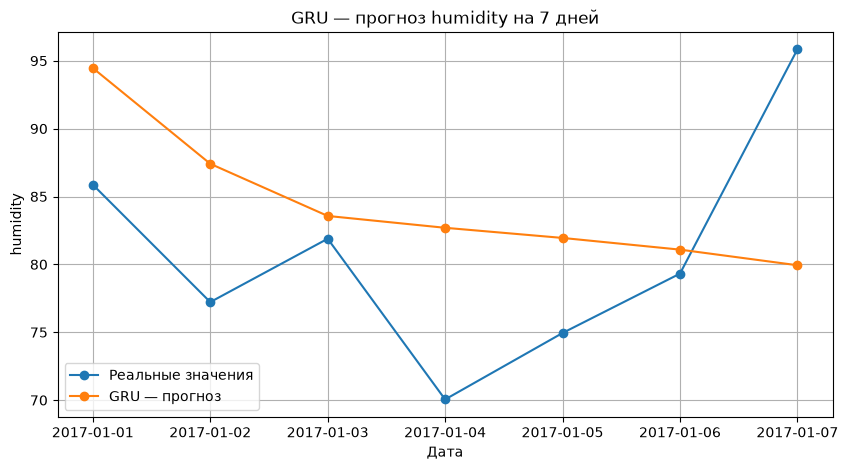

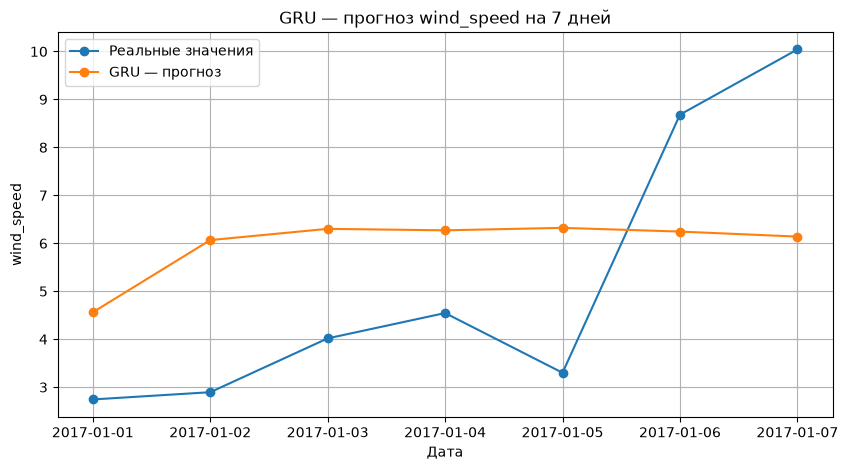

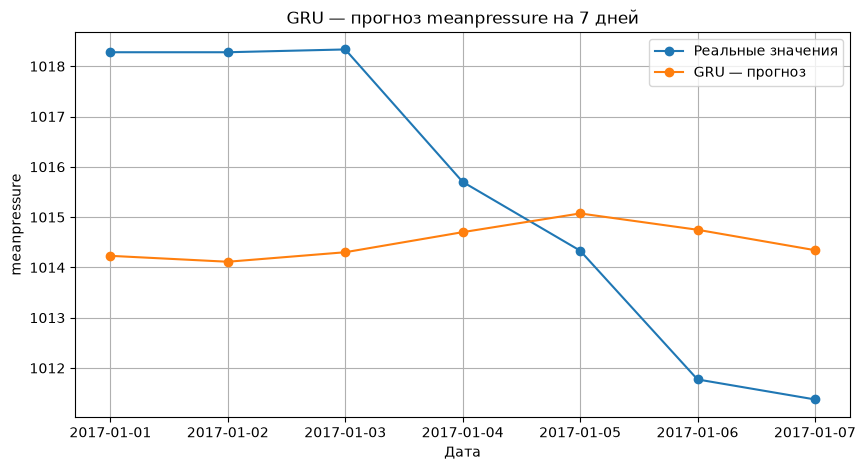

In [19]:
for column in columns:

    horizon = 7
    dates = test["date"].iloc[:horizon]

    plt.figure(figsize=(10, 5))

    plt.plot(
        dates,
        gru_7_results[column]["actual"],
        marker="o",
        label="Реальные значения"
    )

    plt.plot(
        dates,
        gru_7_results[column]["predictions"],
        marker="o",
        label="GRU — прогноз"
    )

    plt.title(f"GRU — прогноз {column} на 7 дней")
    plt.xlabel("Дата")
    plt.ylabel(column)

    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
def run_lstm_multistep(
    train,
    test,
    column,
    window=60,
    horizon=7,
    epochs=100,
    batch_size=32
):

    train_values = train[[column]].values.astype("float32")
    test_values = test[[column]].values.astype("float32")

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train_values)

    X_train, y_train = create_sequences_multistep(
        train_scaled,
        window,
        horizon
    )

    X_train = X_train.reshape(
        X_train.shape[0],
        window,
        1
    )

    split = int(len(X_train) * 0.8)

    X_tr = X_train[:split]
    y_tr = y_train[:split]

    X_val = X_train[split:]
    y_val = y_train[split:]

    model = Sequential([
        Input(shape=(window, 1)),

        LSTM(
            64,
            use_cudnn=False
        ),

        # 7 или 14 выходов одновременно
        Dense(horizon)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop],
        verbose=1
    )

    last_window = train_scaled[-window:]

    x = last_window.reshape(
        1,
        window,
        1
    )

    pred_scaled = model.predict(
        x,
        verbose=0
    )[0]

    predictions = scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).flatten()

    actual = test_values[:horizon].flatten()

    metrics = calculate_metrics(
        actual,
        predictions
    )

    return predictions, actual, metrics, model

In [21]:
lstm_7_results = {}

for column in columns:

    print("\nLSTM 7 дней:", column)

    predictions, actual, metrics, model = run_lstm_multistep(
        train,
        test,
        column,
        window=60,
        horizon=7,
        epochs=100
    )

    lstm_7_results[column] = {
        "predictions": predictions,
        "actual": actual,
        "metrics": metrics
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")


LSTM 7 дней: meantemp
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.1392 - val_loss: 0.0144
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0209 - val_loss: 0.0142
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0133 - val_loss: 0.0086
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0110 - val_loss: 0.0105
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 - val_loss: 0.0070
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_loss: 0.0076
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0088 - val_loss: 0.0066
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084 - val_loss: 0.0063
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0081 - val_loss: 0.0060
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0079 - val_loss: 0.0057
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0077 - val_loss: 0.0054
Epoch 12/100
35/35 ━━━━━━━━━━━━━━━━━━━━

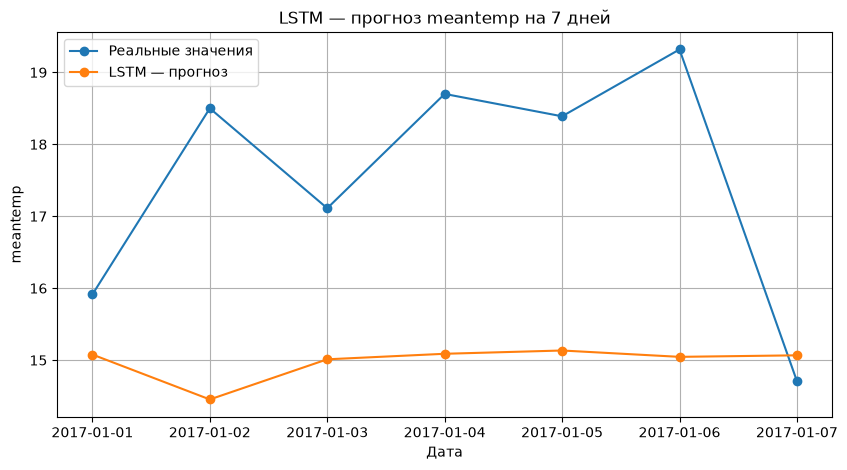

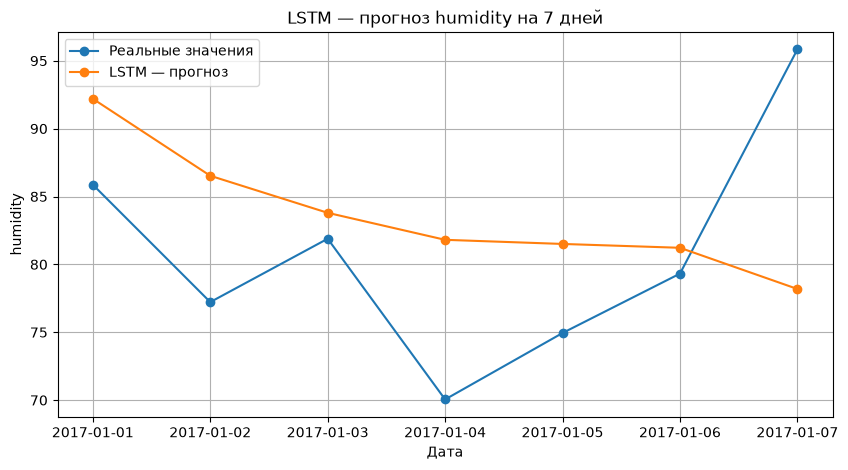

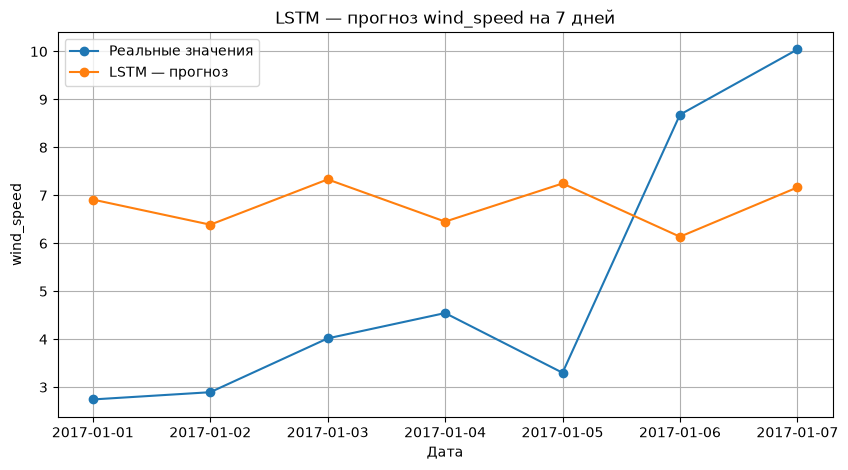

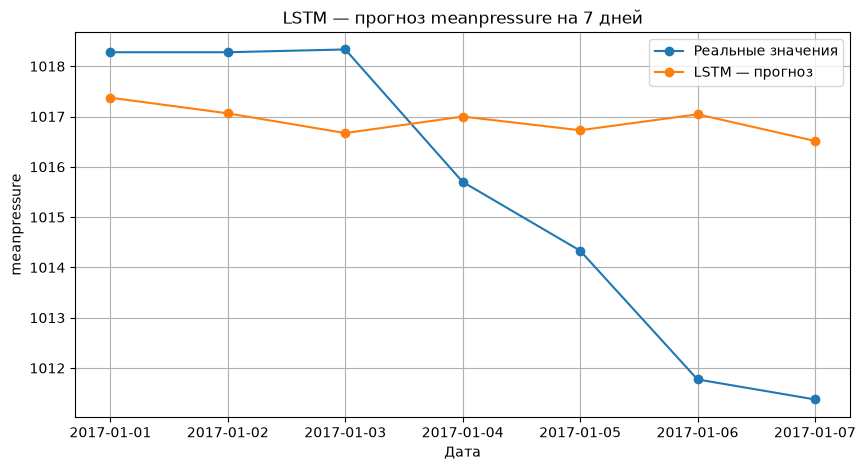

In [22]:
for column in columns:

    horizon = 7
    dates = test["date"].iloc[:horizon]

    plt.figure(figsize=(10, 5))

    plt.plot(
        dates,
        lstm_7_results[column]["actual"],
        marker="o",
        label="Реальные значения"
    )

    plt.plot(
        dates,
        lstm_7_results[column]["predictions"],
        marker="o",
        label="LSTM — прогноз"
    )

    plt.title(f"LSTM — прогноз {column} на 7 дней")
    plt.xlabel("Дата")
    plt.ylabel(column)

    plt.legend()
    plt.grid(True)
    plt.show()

Добавление лагов

In [48]:
for df in [train, test]:

    df["dayofyear"] = df["date"].dt.dayofyear

    df["sin_day"] = np.sin(
        2 * np.pi * df["dayofyear"] / 365.25
    )

    df["cos_day"] = np.cos(
        2 * np.pi * df["dayofyear"] / 365.25
    )

In [49]:
def create_calendar_sequences(
    df,
    target_column,
    window=60,
    horizon=7
):

    feature_columns = [
        target_column,
        "sin_day",
        "cos_day"
    ]

    X = []
    y = []

    feature_values = df[feature_columns].values
    target_values = df[target_column].values

    for i in range(
        window,
        len(df) - horizon + 1
    ):

        X.append(
            feature_values[i-window:i]
        )

        y.append(
            target_values[i:i+horizon]
        )

    return np.array(X), np.array(y), feature_columns

In [50]:
from sklearn.preprocessing import MinMaxScaler

def run_gru_calendar(
    train,
    test,
    column,
    window=60,
    horizon=7,
    epochs=100,
    batch_size=32
):

    feature_columns = [
        column,
        "sin_day",
        "cos_day"
    ]

    x_scaler = MinMaxScaler()

    X_features_scaled = x_scaler.fit_transform(
        train[feature_columns]
    )

    train_scaled = train.copy()

    train_scaled[feature_columns] = X_features_scaled

    y_scaler = MinMaxScaler()

    train_scaled[column] = y_scaler.fit_transform(
        train[[column]]
    )

    X, y, _ = create_calendar_sequences(
        train_scaled,
        column,
        window=window,
        horizon=horizon
    )

    split = int(len(X) * 0.8)

    X_train = X[:split]
    y_train = y[:split]

    X_val = X[split:]
    y_val = y[split:]

    model = Sequential([
        Input(
            shape=(
                window,
                len(feature_columns)
            )
        ),

        GRU(
            64,
            use_cudnn=False
        ),

        Dense(horizon)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        validation_data=(
            X_val,
            y_val
        ),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop],
        verbose=1
    )

    last_window = train[
        feature_columns
    ].iloc[-window:].values

    last_window_scaled = x_scaler.transform(
        last_window
    )

    x = last_window_scaled.reshape(
        1,
        window,
        len(feature_columns)
    )

    pred_scaled = model.predict(
        x,
        verbose=0
    )[0]

    predictions = y_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).flatten()

    actual = test[column].iloc[
        :horizon
    ].values

    metrics = calculate_metrics(
        actual,
        predictions
    )

    return predictions, actual, metrics, model

In [51]:
gru_calendar_results = {}

for column in columns:

    print("\nGRU + календарь:", column)

    predictions, actual, metrics, model = run_gru_calendar(
        train,
        test,
        column,
        window=60,
        horizon=7,
        epochs=100
    )

    gru_calendar_results[column] = {
        "predictions": predictions,
        "actual": actual,
        "metrics": metrics
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")


GRU + календарь: meantemp
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.1693 - val_loss: 0.0231
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0203 - val_loss: 0.0069
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065 - val_loss: 0.0067
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059 - val_loss: 0.0059
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0057 - val_loss: 0.0051
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0058 - val_loss: 0.0054
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059 - val_loss: 0.0052
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0058 - val_loss: 0.0051
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0058 - val_loss: 0.0050
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0058 - val_loss: 0.0050
Epoch 12/100
35/35 ━━━━━━━━━━━━━━━━

/home/mlguest/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


MAE: 4.9853
MSE: 27.6267
RMSE: 5.2561
R2: -10.3783
MAPE: 27.8588

GRU + календарь: humidity
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1039 - val_loss: 0.0476
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0346 - val_loss: 0.0301
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0232 - val_loss: 0.0219
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0187 - val_loss: 0.0185
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0174 - val_loss: 0.0176
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0172 - val_loss: 0.0171
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0169 - val_loss: 0.0167
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0167 - val_loss: 0.0164
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0166 - val_loss: 0.0161
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0165 - val_loss: 0.0159
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - lo

/home/mlguest/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


MAE: 7.6724
MSE: 77.1428
RMSE: 8.7831
R2: -0.2928
MAPE: 9.5641

GRU + календарь: wind_speed
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0177 - val_loss: 0.0121
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0116 - val_loss: 0.0100
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0107 - val_loss: 0.0094
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104 - val_loss: 0.0092
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0103 - val_loss: 0.0092
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0103 - val_loss: 0.0092
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104 - val_loss: 0.0093
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0106 - val_loss: 0.0092
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0105 - val_loss: 0.0092
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 - val_loss: 0.0092
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - lo

/home/mlguest/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


MAE: 2.0069
MSE: 8.3522
RMSE: 2.8900
R2: -0.1168
MAPE: 32.2739

GRU + календарь: meanpressure
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1971 - val_loss: 0.0127
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0079 - val_loss: 0.0064
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.0048
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015 - val_loss: 0.0044
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0042
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.1885e-04 - val_loss: 0.0042
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.8028e-04 - val_loss: 0.0042
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.7672e-04 - val_loss: 0.0042
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.9117e-04 - val_loss: 0.0042
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.1564e-04 - val_loss: 0.0042
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━

/home/mlguest/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


MAE: 2.7701
MSE: 11.0304
RMSE: 3.3212
R2: -0.3852
MAPE: 0.2733


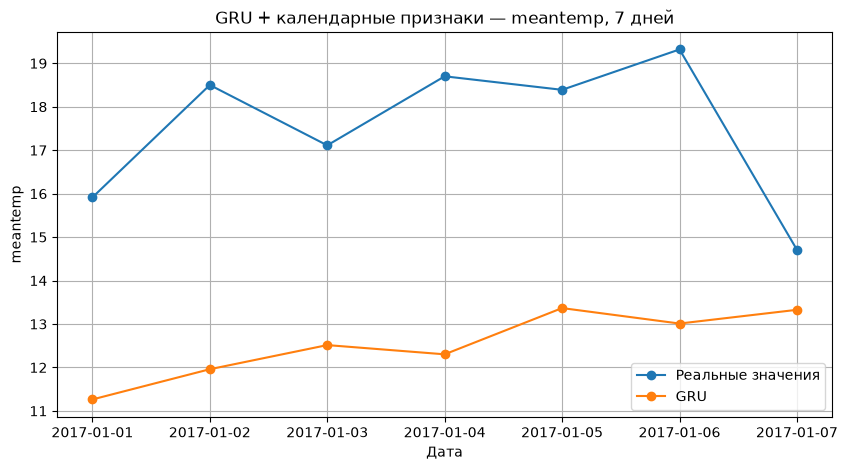

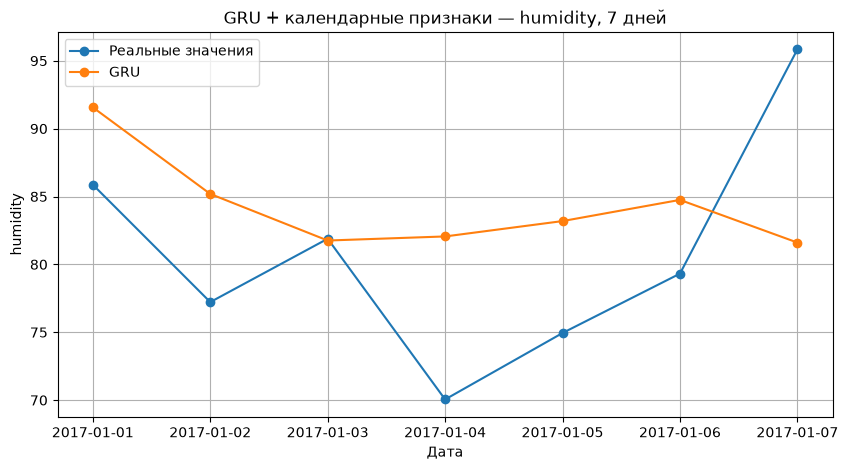

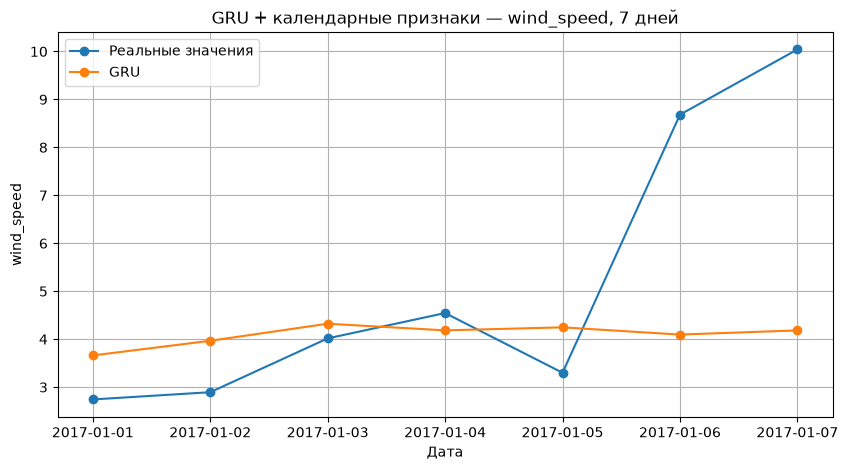

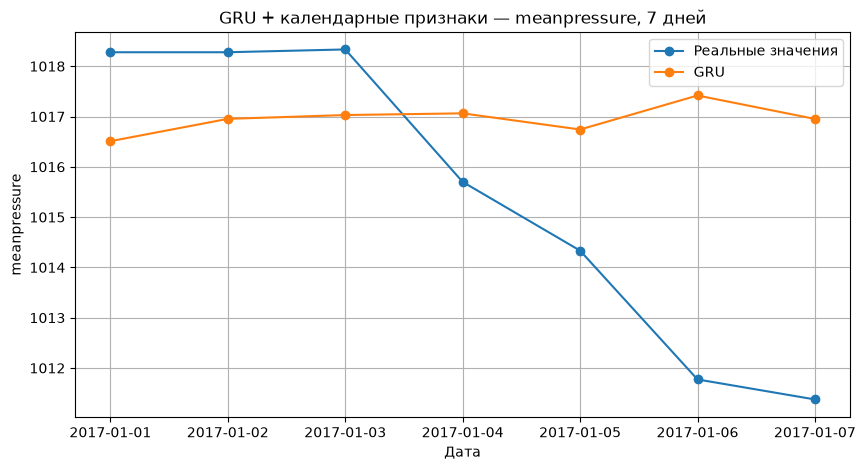

In [52]:
for column in columns:

    dates = test["date"].iloc[:7]

    plt.figure(figsize=(10, 5))

    plt.plot(
        dates,
        gru_calendar_results[column]["actual"],
        marker="o",
        label="Реальные значения"
    )

    plt.plot(
        dates,
        gru_calendar_results[column]["predictions"],
        marker="o",
        label="GRU"
    )

    plt.title(
        f"GRU + календарные признаки — {column}, 7 дней"
    )

    plt.xlabel("Дата")
    plt.ylabel(column)

    plt.grid(True)
    plt.legend()
    plt.show()